# Part 2: Coupled Firing Rate Neuron Model
In [2], a possible model for a network of neurons is given as follows: let $N>0 \in \mathbb N$ be fixed, then
$$
\forall i = 1,\ldots, N: \tau \frac{\text{d} r_i}{\text{d} t}(t) = - r_i(t) + \Phi\left(\sum_{j = 1,\ldots, N} W_{ij} r_j(t) + I_i(t)\right)
$$
The term $W_{ij}$ represents the connections between the neurons, the term $\Phi$ is the the firing rate function and $I_i$ are the external impulses (can be time-valued functions).

In a certain sense, this is the discretization of the following model which represents a "dense" network of neurons ([1]):

$$
\tau \frac{\partial r}{\partial t}(t, x) = - r(t, x) + \Phi\left(\int_\Omega K(|x-y|) r(t, y)\text{ d}y + I(x,t)\right)
$$

In fact one of its possible realisations is the ring model, as in [1]. However, studying this type of model requires techniques to solve Integro-Differential equations (IDEs) and will therefore be studied in a possible third part (to see).

> N.B. Interesting [library](https://github.com/emazap7/NIDE) to solve IDEs, which also seems to be compatible with Pytorch (i.e. differentiable). Will see if it's worth it later on

We will take $\tau = 1$ to simplify and as in [2] we will consider $Phi$ to be as follows:
$$
\Phi(x)=(1+e^{-x})^{-1}
$$
More commonly known as the SIGMOID function

In this notebook we will firstly simulate said model for some parameters, and then apply UDEs to learn the impulses, the weights and the firing rate function.

In [1]:
# Import the necessary modules
import numpy as np 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch 
from torch import nn, optim
from torchdiffeq import odeint
from functools import partial

## Experiment 1: Winner-take-all Mechanism
In [1], the following model describes the "winner-take-all" mechanism:
$$
\begin{align*}
&\tau \frac{\text{d}r_1}{\text{d}t} = -r_1 + \Phi(I_0-Jr_2) \\
&\tau \frac{\text{d}r_2}{\text{d}t} = -r_2 + \Phi(I_0-Jr_1)
\end{align*}
$$
That is, two inhibitory neurons are connected with $J>0$ being the magnitude of recurrent inhibition. It can be shown that there's a homegeneous steady state $r_s$ with $r_s = \Phi(I_0 - J r_s)$. However, with a strong enough inhibition steady state is unstable and thus there are two possible coexisting attractors, with one being a symmetric one and the other one being a situation where one subnetwork's activity is suppressed and the other is enhanched.

In [9]:
# Part 1: Simulate neuron networks

# Winner take all mechanism [1]

def NP_firing_rate_fun(x):
    return 1 / (1 + np.exp(-x))

def many_monkeys_simple(t, data, phi, I, J):
    # Assume I0, J are constants
    r1 = data[0]
    r2 = data[1]

    try: 
        I(0)
    except: 
        return np.array([
            -r1 + phi(I - J*r2),
            -r2 + phi(I - J*r1),
        ])
    else:
        return np.array([
            -r1 + phi(I(t) - J*r2),
            -r2 + phi(I(t) - J*r1),
        ])


In [37]:
I0 = 2
J = 10
r_init = [1, 1]
T_MAX = 25

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]


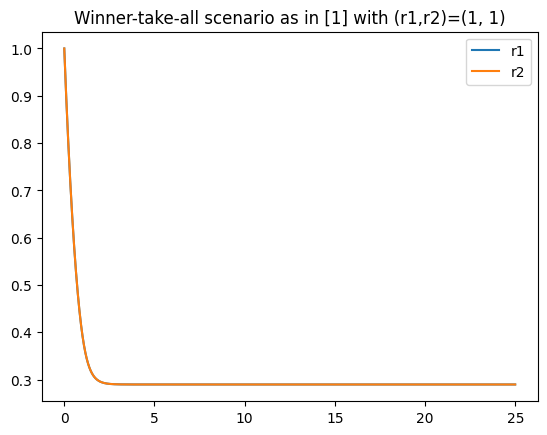

In [39]:
plt.plot(sol.t, r1, label="r1")
plt.plot(sol.t, r2, label="r2")

plt.title("Winner-take-all scenario as in [1] with (r1,r2)=(1, 1)")
plt.legend()

plt.show()

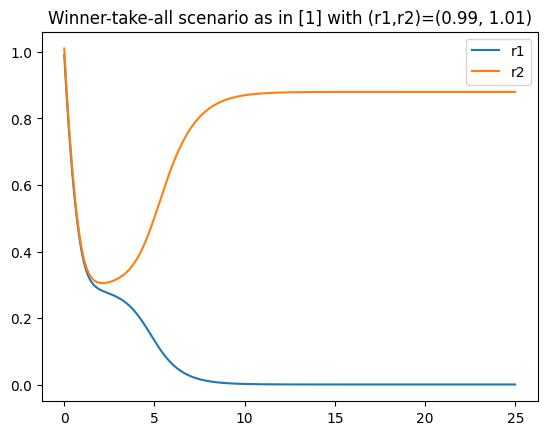

In [40]:
I0 = 2
J = 10
r_init = [0.99, 1.01]
T_MAX = 25

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]

plt.plot(sol.t, r1, label="r1")
plt.plot(sol.t, r2, label="r2")

plt.title("Winner-take-all scenario as in [1] with (r1,r2)=(0.99, 1.01)")
plt.legend()

plt.show()

### Case 1: Homogenous Steady state

Here we will try to generate a training set for both of the cases, and attempt to train an UDE on the dataset to learn the hidden firing rate function $\Phi$.

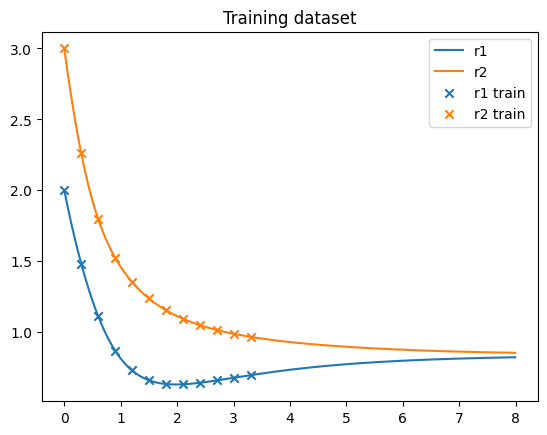

In [200]:
# Generate training data for UDE
I0 = 5
J = 4
r_init = [2, 3]
T_MAX = 8

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]

data_train = sol.y[:, :350:30]
t_train = sol.t[:350:30]

plt.plot(sol.t, r1, label="r1")
plt.plot(sol.t, r2, label="r2")

plt.scatter(t_train, data_train[0, : ], label="r1 train", marker="x")
plt.scatter(t_train, data_train[1, : ], label="r2 train", marker="x")

plt.title("Training dataset")
plt.legend()

plt.show()

In [201]:
# Define pytorch class and necessary functions

In [202]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class learning_winnertakeall_monkeys(nn.Module):
    def __init__(self, I0, J):
        super().__init__()

        self.register_buffer("I0", torch.tensor([I0], dtype=torch.float32))
        self.register_buffer("J", torch.tensor([J], dtype=torch.float32))

        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 1),
            nn.Softplus()
        )

    def forward(self, t, data):
        activation_r1 = self.net(self.I0 - self.J*data[1]).squeeze()
        activation_r2 = self.net(self.I0 - self.J*data[0]).squeeze()
        out = -data + torch.stack((activation_r1, activation_r2), dim=-1)
        return out


In [203]:
# Train UDE network to training data
from tqdm import tqdm 
my_fighting_monkeys_exp1 = learning_winnertakeall_monkeys(I0, J)

lr = 1e-3
optimizer = torch.optim.Adam(my_fighting_monkeys_exp1.parameters(), lr)

x0_torch = torch.tensor(r_init, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
N_data = torch.tensor(11., requires_grad=False)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T

for EPOCH in (range(1, 1000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_fighting_monkeys_exp1, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}")
        pass


1	5.148994E-02
2	5.033073E-02
3	4.920348E-02
4	4.810622E-02
5	4.703747E-02
6	4.599795E-02
7	4.498556E-02
8	4.400220E-02
9	4.304402E-02
10	4.211295E-02
11	4.120612E-02
12	4.032395E-02
13	3.946683E-02
14	3.863205E-02
15	3.781875E-02
16	3.702908E-02
17	3.625959E-02
18	3.551050E-02
19	3.478100E-02
20	3.407042E-02
21	3.337848E-02
22	3.270392E-02
23	3.204667E-02
24	3.140608E-02
25	3.078095E-02
26	3.017149E-02
27	2.957673E-02
28	2.899610E-02
29	2.843005E-02
30	2.787646E-02
31	2.733509E-02
32	2.680660E-02
33	2.629002E-02
34	2.578556E-02
35	2.529079E-02
36	2.480717E-02
37	2.433421E-02
38	2.387093E-02
39	2.341730E-02
40	2.297306E-02
41	2.253774E-02
42	2.211101E-02
43	2.169284E-02
44	2.128284E-02
45	2.088070E-02
46	2.048610E-02
47	2.009895E-02
48	1.971995E-02
49	1.934651E-02
50	1.898004E-02
51	1.862093E-02
52	1.826796E-02
53	1.792125E-02
54	1.758065E-02
55	1.724599E-02
56	1.691715E-02
57	1.659402E-02
58	1.627693E-02
59	1.596449E-02
60	1.565769E-02
61	1.535622E-02
62	1.505993E-02
63	1.476868E-02
6

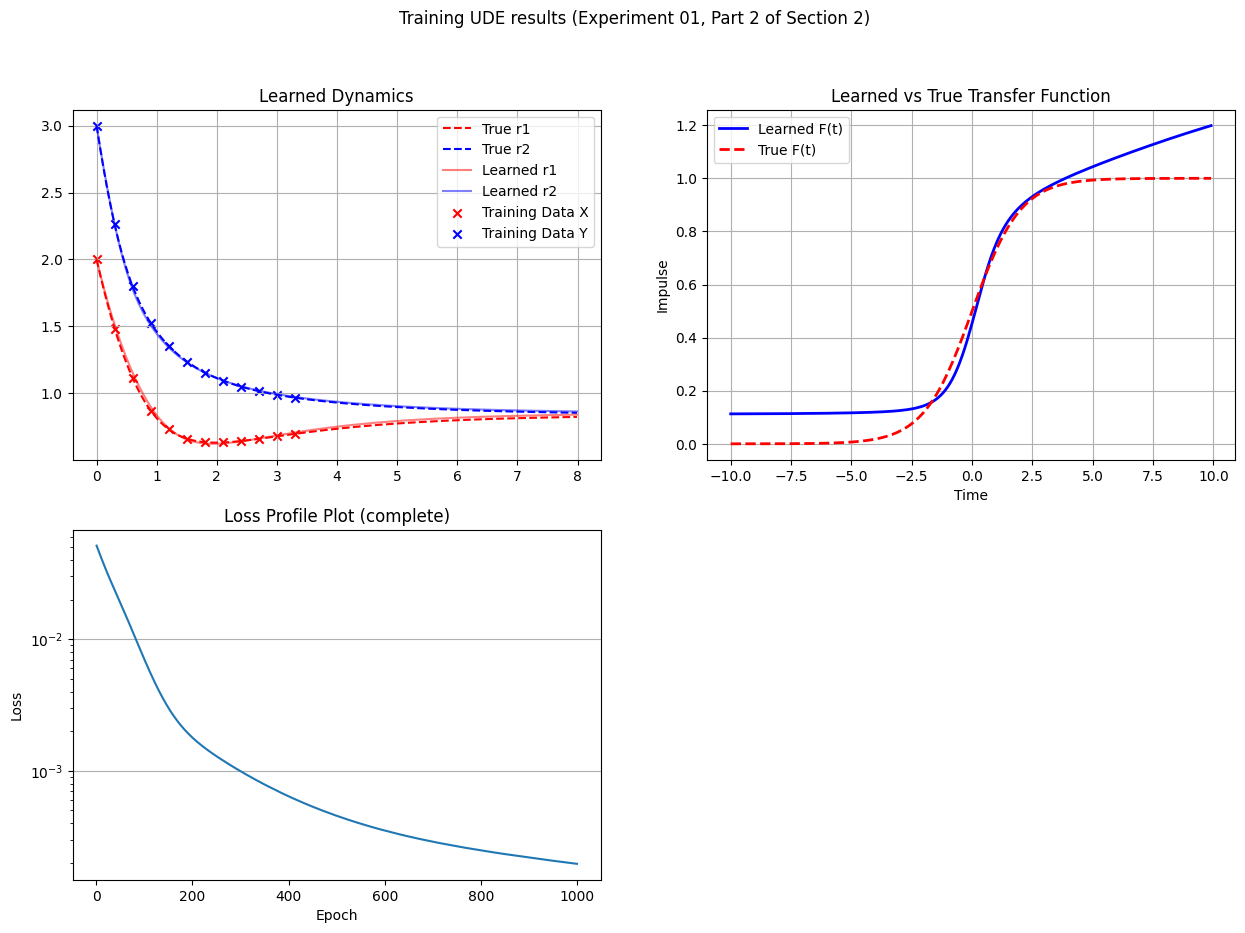

In [224]:
plt.figure(figsize=(15, 10))
plt.suptitle("Training UDE results (Experiment 01, Part 2 of Section 2)")

pred = odeint(my_fighting_monkeys_exp1, x0_torch, torch.arange(0, 8, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

plt.subplot(2, 2, 1)
plt.plot(sol.t, r1, "r--", label="True r1")
plt.plot(sol.t, r2, "b--", label="True r2")

plt.plot(np.arange(0, 8, 0.01), pred[:, 0].cpu().detach().numpy(), label="Learned r1", color="r", alpha=0.5)
plt.plot(np.arange(0, 8, 0.01), pred[:, 1].cpu().detach().numpy(), label="Learned r2", color="b", alpha=0.5)

plt.scatter(t_train, data_train[0, :],marker="x", color="r", label="Training Data X")
plt.scatter(t_train, data_train[1, :],marker="x", color="b", label="Training Data Y")

plt.grid()

plt.title("Learned Dynamics")
plt.legend()



i_plot = torch.arange(-10, 10, 0.1)
with torch.no_grad():
    act_learned = torch.stack([my_fighting_monkeys_exp1.net(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

# Plot 1: Learned Activation vs true activation
plt.subplot(2, 2, 2)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-10, 10, 0.1)

act_true = NP_firing_rate_fun(i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Time')
plt.ylabel('Impulse')
plt.legend()
plt.title('Learned vs True Transfer Function')
plt.grid()

# Plot 3: losses with semilogy
losses_data = np.loadtxt(r".\losses\my_fighting_monkeys_exp1_losses.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.title("Loss Profile Plot (complete)")

plt.show()

plt.show()


In [232]:
torch.save(my_fighting_monkeys_exp1.state_dict(), "./models_weights/my_fighting_monkeys_exp1.dinomeng")

### Case 2: Winner-take-all ending

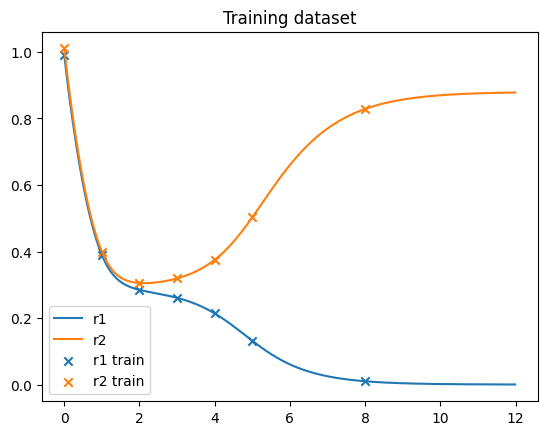

In [359]:
I0 = 2
J = 10
r_init = [0.99, 1.01]
T_MAX = 12

sol = solve_ivp(
    many_monkeys_simple,
    t_span = [0, T_MAX],
    y0 = np.array(r_init), 
    t_eval = np.arange(0, T_MAX, 0.01),
    args = (NP_firing_rate_fun, I0, J),
    atol=1e-8, rtol=1e-8
)

r1 = sol.y[0, :]
r2 = sol.y[1, :]

data_train = (sol.y[:, :551:100]).T
data_train = np.vstack((data_train, sol.y.T[-400, :]))

t_train = (sol.t[:551:100])
t_train = np.append(t_train, sol.t[-400])

plt.plot(sol.t, r1, label="r1")
plt.plot(sol.t, r2, label="r2")

plt.scatter(t_train, data_train[:, 0], label="r1 train", marker="x")
plt.scatter(t_train, data_train[:, 1], label="r2 train", marker="x")

plt.title("Training dataset")
plt.legend()

plt.show()

In [360]:
# Train UDE network to training data
from tqdm import tqdm 
my_fighting_monkeys_exp2 = learning_winnertakeall_monkeys(I0, J)

lr = 0.005
optimizer = torch.optim.Adam(my_fighting_monkeys_exp2.parameters(), lr)

x0_torch = torch.tensor(r_init, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
N_data = torch.tensor(11., requires_grad=False)
data_train_torch = torch.tensor(data_train, dtype=torch.float32)

for EPOCH in (range(1, 1000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(my_fighting_monkeys_exp2, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='dopri5')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}")
        pass


1	2.503186E-01
2	2.095848E-01
3	1.758500E-01
4	1.481365E-01
5	1.254615E-01
6	1.070265E-01
7	9.216827E-02
8	8.030029E-02
9	7.089613E-02
10	6.348772E-02
11	5.766837E-02
12	5.309765E-02
13	4.949838E-02
14	4.665166E-02
15	4.438788E-02
16	4.257651E-02
17	4.111811E-02
18	3.993643E-02
19	3.897278E-02
20	3.818244E-02
21	3.753028E-02
22	3.698819E-02
23	3.653474E-02
24	3.615242E-02
25	3.582697E-02
26	3.554703E-02
27	3.530321E-02
28	3.508732E-02
29	3.489301E-02
30	3.471475E-02
31	3.454747E-02
32	3.438753E-02
33	3.423081E-02
34	3.407397E-02
35	3.391385E-02
36	3.374697E-02
37	3.357007E-02
38	3.337901E-02
39	3.316941E-02
40	3.293560E-02
41	3.267042E-02
42	3.236475E-02
43	3.200545E-02
44	3.157585E-02
45	3.105123E-02
46	3.039704E-02
47	2.956284E-02
48	2.847750E-02
49	2.704442E-02
50	2.515057E-02
51	2.270835E-02
52	1.976080E-02
53	1.656471E-02
54	1.350919E-02
55	1.086978E-02
56	8.705587E-03
57	6.951550E-03
58	5.528302E-03
59	4.390299E-03
60	3.527234E-03
61	2.945847E-03
62	2.646957E-03
63	2.608413E-03
6

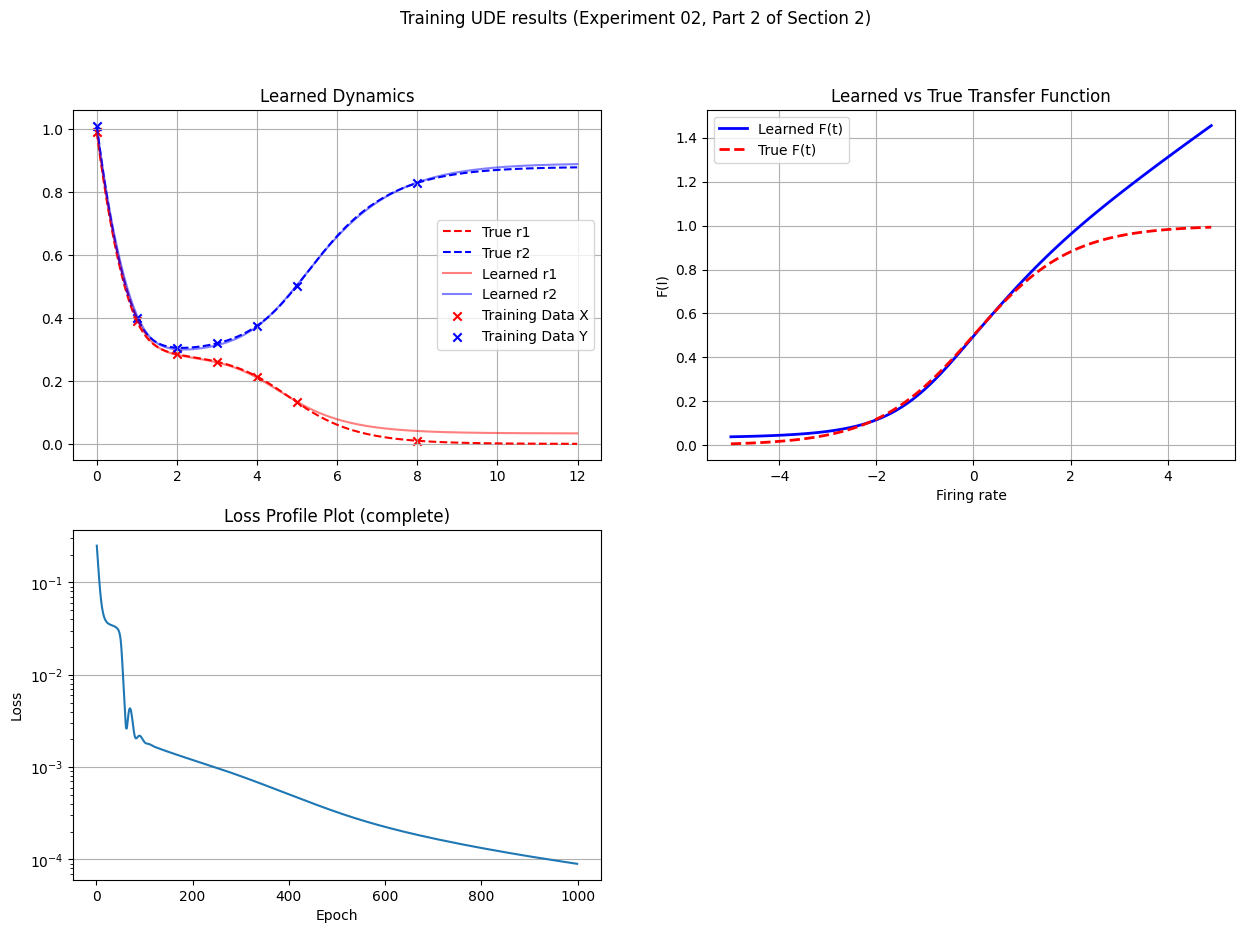

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle("Training UDE results (Experiment 02, Part 2 of Section 2)")

pred = odeint(my_fighting_monkeys_exp2, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

plt.subplot(2, 2, 1)
plt.plot(sol.t, r1, "r--", label="True r1")
plt.plot(sol.t, r2, "b--", label="True r2")

plt.plot(np.arange(0, T_MAX, 0.01), pred[:, 0].cpu().detach().numpy(), label="Learned r1", color="r", alpha=0.5)
plt.plot(np.arange(0, T_MAX, 0.01), pred[:, 1].cpu().detach().numpy(), label="Learned r2", color="b", alpha=0.5)

plt.scatter(t_train, data_train[:, 0],marker="x", color="r", label="Training Data X")
plt.scatter(t_train, data_train[:, 1],marker="x", color="b", label="Training Data Y")

plt.grid()

plt.title("Learned Dynamics")
plt.legend()



i_plot = torch.arange(-5, 5, 0.1)
with torch.no_grad():
    act_learned = torch.stack([my_fighting_monkeys_exp2.net(torch.tensor([[I]], dtype=torch.float32)) 
                             for I in i_plot]).squeeze()

# Plot 1: Learned Activation vs true activation
plt.subplot(2, 2, 2)
plt.plot(i_plot.numpy(), act_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')

i_true = np.arange(-5, 5, 0.1)

act_true = NP_firing_rate_fun(i_true)

plt.plot(i_true, act_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('Firing rate')
plt.ylabel('F(I)')
plt.legend()
plt.title('Learned vs True Transfer Function')
plt.grid()

# Plot 3: losses with semilogy
losses_data = np.loadtxt(r".\losses\my_fighting_monkeys_exp2_losses.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.title("Loss Profile Plot (complete)")

plt.show()

plt.show()


In [363]:
torch.save(my_fighting_monkeys_exp2.state_dict(), "./models_weights/my_fighting_monkeys_exp2.dinomeng")

## Experiment 02: Big Neuron Networks
This time let's expand $N$ as much as possible, with a randomly defined weight matrix and our goal is to learn the weight matrix as well as the other factors (impulse function, activation function, et cetera...)

### Case 1: Learning Only Weights
In this case we define $\tau = 1$ globally, $I_k$ (constant), $W_{ij}$ randomly and $\Phi$ as the same function considered in the previous case.

In [226]:

def NP_firing_rate_fun(x):
    return 1 / (1 + np.exp(-x))

def many_monkeys(t, data, weights, phi, I):
    # Assume I is a vector of constants

    return np.array([
        - data[i] + phi( I[i] + np.sum([ weights[i,j] * data[j] for j in range(data.shape[0]) ])
        ) for i in range(data.shape[0])
    ]) 

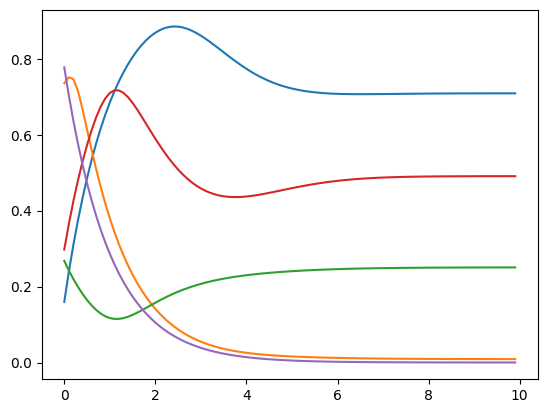

In [496]:
T_MAX = 10
NEURON_NUM = 5

W = np.random.random((NEURON_NUM, NEURON_NUM))*10
mask = np.random.random((NEURON_NUM, NEURON_NUM)) >= 0.33

W[mask] *= -1 

I = np.abs(np.random.random(NEURON_NUM))

initial_state = np.abs(np.random.random(NEURON_NUM) * 1)

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = initial_state, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(W, NP_firing_rate_fun, I),
                atol = 1e-8, rtol=1e-8)

for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i])

In [ ]:
# W_very_cool = W.copy()
# I_very_cool = I.copy()
# y0_very_cool = initial_state.copy()
# 
# np.savetxt("./cool_parameters/W.np", W_very_cool)
# np.savetxt("./cool_parameters/I.np", I_very_cool)
# np.savetxt("./cool_parameters/x0.np", y0_very_cool)
# 

Text(0.5, 1.0, 'Weights matrix (randomly generated)')

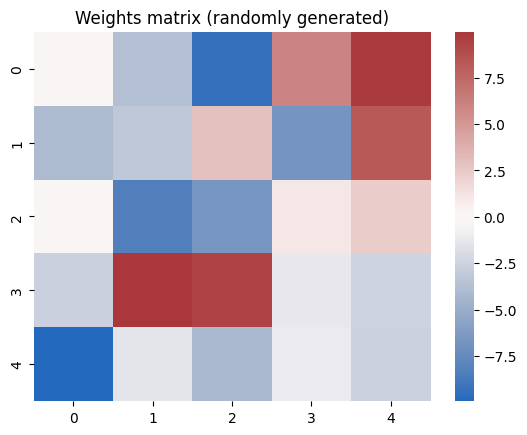

In [497]:
import seaborn as sns

sns.heatmap(W, cmap="vlag")
plt.title("Weights matrix (randomly generated)")

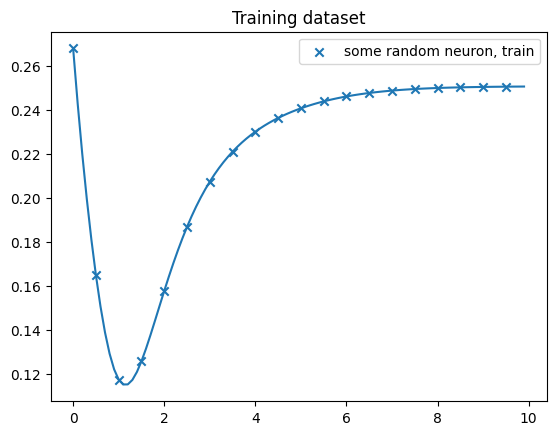

In [498]:
sol = solve_ivp(many_monkeys, [0, T_MAX],
                y0 = initial_state, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(W, NP_firing_rate_fun, I),
                atol = 1e-8, rtol=1e-8)

i_rand = np.random.randint(low = 0, high = NEURON_NUM)

plt.plot(sol.t, sol.y[i_rand])

data_train = sol.y[:, ::5]
t_train = sol.t[::5]

plt.scatter(t_train, data_train[i_rand, :], label="some random neuron, train", marker="x")

plt.title("Training dataset")
plt.legend()

plt.show()

In [499]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class learning_many_monkeys(nn.Module):
    def __init__(self, F, I0):
        super().__init__()


        self.register_buffer("I0", torch.tensor([I0], dtype=torch.float32))
        self.F = F

        self.register_parameter("W", nn.Parameter(torch.rand((NEURON_NUM, NEURON_NUM))))
        # self.register_parameter("W", nn.Parameter(torch.tensor(W_very_cool, dtype=torch.float32))) - cheating mode

    def forward(self, t, data):
        return - data + self.F(self.I0 + self.W @ data.squeeze())


In [501]:
# Train (fake) UDE network to training data
from tqdm import tqdm 
many_monkeys_weights = learning_many_monkeys(TORCH_firing_rate_fun, I)

lr = 0.05
optimizer = torch.optim.Adam(many_monkeys_weights.parameters(), lr=lr)

x0_torch = torch.tensor(initial_state, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T

print("Epoch\tLoss (L2 norm)\tFrobenius Norm (Weight matrixes)")
for EPOCH in (range(1, 5000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(many_monkeys_weights, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}\t{torch.sqrt(torch.sum(torch.pow(many_monkeys_weights.W - torch.tensor(W), 2))):4f}")
        pass


Epoch	Loss (L2 norm)	Frobenius Norm (Weight matrixes)
1	4.135218E-01	29.677074
2	3.985521E-01	29.626627
3	3.805451E-01	29.578210
4	3.594280E-01	29.531781
5	3.354906E-01	29.487254
6	3.094932E-01	29.444463
7	2.826302E-01	29.403104
8	2.562649E-01	29.362655
9	2.315038E-01	29.322402
10	2.088715E-01	29.281741
11	1.883817E-01	29.240426
12	1.698715E-01	29.198485
13	1.531854E-01	29.156072
14	1.381834E-01	29.113388
15	1.247229E-01	29.070646
16	1.126580E-01	29.028054
17	1.018458E-01	28.985803
18	9.215291E-02	28.944061
19	8.345806E-02	28.902972
20	7.565331E-02	28.862660
21	6.864354E-02	28.823226
22	6.234537E-02	28.784755
23	5.668594E-02	28.747316
24	5.160160E-02	28.710964
25	4.703673E-02	28.675745
26	4.294261E-02	28.641693
27	3.927638E-02	28.608834
28	3.600006E-02	28.577186
29	3.307965E-02	28.546760
30	3.048429E-02	28.517557
31	2.818558E-02	28.489574
32	2.615687E-02	28.462799
33	2.437282E-02	28.437213
34	2.280904E-02	28.412793
35	2.144189E-02	28.389508
36	2.024841E-02	28.367322
37	1.920646E-02	28.

In [502]:
for EPOCH in (range(5000, 10000)): # seems to work, keep going for 10000 epochs
    optimizer.zero_grad()

    # get forward solution
    info = odeint(many_monkeys_weights, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}\t{torch.sqrt(torch.sum(torch.pow(many_monkeys_weights.W - torch.tensor(W), 2))):4f}")
        pass

5000	1.317004E-05	21.082091
5001	1.316411E-05	21.081634
5002	1.315811E-05	21.081177
5003	1.315217E-05	21.080721
5004	1.314620E-05	21.080264
5005	1.314024E-05	21.079808
5006	1.313431E-05	21.079351
5007	1.312834E-05	21.078894
5008	1.312242E-05	21.078438
5009	1.311643E-05	21.077981
5010	1.311048E-05	21.077524
5011	1.310459E-05	21.077067
5012	1.309862E-05	21.076611
5013	1.309273E-05	21.076154
5014	1.308677E-05	21.075698
5015	1.308083E-05	21.075241
5016	1.307493E-05	21.074784
5017	1.306898E-05	21.074328
5018	1.306309E-05	21.073871
5019	1.305716E-05	21.073414
5020	1.305123E-05	21.072958
5021	1.304535E-05	21.072501
5022	1.303944E-05	21.072044
5023	1.303354E-05	21.071588
5024	1.302763E-05	21.071131
5025	1.302174E-05	21.070674
5026	1.301584E-05	21.070218
5027	1.300995E-05	21.069761
5028	1.300405E-05	21.069304
5029	1.299816E-05	21.068848
5030	1.299229E-05	21.068391
5031	1.298638E-05	21.067934
5032	1.298050E-05	21.067478
5033	1.297462E-05	21.067021
5034	1.296876E-05	21.066564
5035	1.296288E-05	21

In [503]:
for EPOCH in (range(10000, 20000)): # 10k more epochs vro
    optimizer.zero_grad()

    # get forward solution
    info = odeint(many_monkeys_weights, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}\t{torch.sqrt(torch.sum(torch.pow(many_monkeys_weights.W - torch.tensor(W), 2))):4f}")
        pass

10000	1.497353E-06	18.415561
10001	1.496480E-06	18.414870
10002	1.495632E-06	18.414178
10003	1.494780E-06	18.413486
10004	1.493928E-06	18.412795
10005	1.493062E-06	18.412103
10006	1.492201E-06	18.411411
10007	1.491364E-06	18.410719
10008	1.490494E-06	18.410027
10009	1.489644E-06	18.409335
10010	1.488785E-06	18.408642
10011	1.487936E-06	18.407950
10012	1.487074E-06	18.407258
10013	1.486218E-06	18.406565
10014	1.485359E-06	18.405872
10015	1.484496E-06	18.405180
10016	1.483646E-06	18.404487
10017	1.482788E-06	18.403794
10018	1.481921E-06	18.403100
10019	1.481065E-06	18.402408
10020	1.480209E-06	18.401714
10021	1.479360E-06	18.401021
10022	1.478490E-06	18.400328
10023	1.477647E-06	18.399634
10024	1.476778E-06	18.398941
10025	1.475910E-06	18.398247
10026	1.475063E-06	18.397554
10027	1.474202E-06	18.396860
10028	1.473340E-06	18.396166
10029	1.472484E-06	18.395472
10030	1.471624E-06	18.394778
10031	1.470766E-06	18.394084
10032	1.469906E-06	18.393390
10033	1.469042E-06	18.392696
10034	1.468173

In [509]:
for EPOCH in (range(20000, 30000)): # 10k more epochs vro
    optimizer.zero_grad()

    # get forward solution
    info = odeint(many_monkeys_weights, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.mean((info - data_train_torch) ** 2)
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{torch.norm(loss_norm, 2):.6E}\t{torch.sqrt(torch.sum(torch.pow(many_monkeys_weights.W - torch.tensor(W), 2))):4f}")
        pass

20000	2.572846E-08	15.502700
20001	2.632932E-08	15.502455
20002	2.719483E-08	15.502263
20003	2.843911E-08	15.502007
20004	3.026175E-08	15.501828
20005	3.290961E-08	15.501557
20006	3.685707E-08	15.501397
20007	4.264639E-08	15.501102
20008	5.142871E-08	15.500971
20009	6.439083E-08	15.500642
20010	8.436412E-08	15.500555
20011	1.137813E-07	15.500172
20012	1.596064E-07	15.500152
20013	2.258659E-07	15.499691
20014	3.290423E-07	15.499770
20015	4.706288E-07	15.499198
20016	6.846764E-07	15.499413
20017	9.414298E-07	15.498708
20018	1.289208E-06	15.499064
20019	1.571378E-06	15.498257
20020	1.822425E-06	15.498653
20021	1.718601E-06	15.497887
20022	1.395585E-06	15.498084
20023	7.947784E-07	15.497559
20024	2.789721E-07	15.497369
20025	3.837080E-08	15.497174
20026	1.280962E-07	15.496668
20027	4.069206E-07	15.496707
20028	6.400880E-07	15.496131
20029	6.938710E-07	15.496170
20030	5.046780E-07	15.495733
20031	2.391447E-07	15.495572
20032	5.368698E-08	15.495339
20033	4.673612E-08	15.494958
20034	1.741186

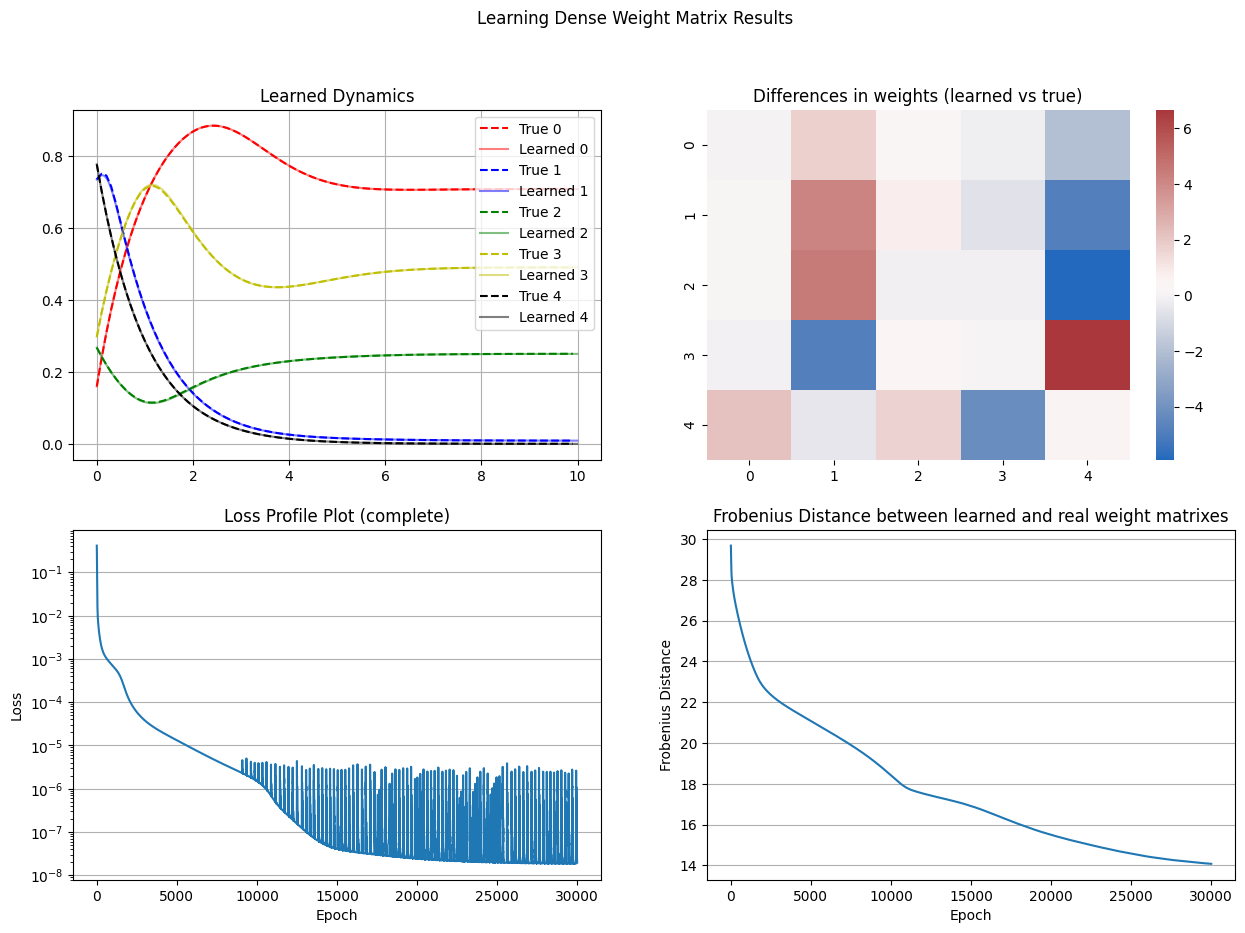

In [530]:
plt.figure(figsize=(15, 10))
plt.suptitle("Learning Dense Weight Matrix Results")

pred = odeint(many_monkeys_weights, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

plt.subplot(2, 2, 1)

colors = ['r', 'b', 'g', 'y', 'k']

for i in range(5):
    plt.plot(sol.t, sol.y[i, :], f"{colors[i]}--", label=f"True {i}")
    plt.plot(np.arange(0, T_MAX, 0.01), pred[:, i].cpu().detach().numpy(), f"{colors[i]}",label=f"Learned {i}", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend()

# Plot 2: Plot difference between weight matrixes

plt.subplot(2,2, 2)

with torch.no_grad():
    sns.heatmap(((many_monkeys_weights.W.detach().numpy()- W)), cmap="vlag")
plt.title("Differences in weights (learned vs true)")


# Plot 3: losses with semilogy
losses_data = np.loadtxt(r"./losses/many_monkeys_weights_losses.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.title("Loss Profile Plot (complete)")


plt.subplot(2,2, 4)
plt.plot(losses_data[:, 0], losses_data[:, 2])
plt.xlabel("Epoch")
plt.ylabel("Frobenius Distance")
plt.title("Frobenius Distance between learned and real weight matrixes")
plt.grid(axis="y")

plt.show()


In [518]:
torch.save(many_monkeys_weights.state_dict(), "./models_weights/many_monkeys_weights_sparse.dinomeng")

### Case 2: Weights + Activation

However, usually a more hybrid situation is verified; i.e., we require a model that learns the weights, f.i. function and the impulses at the same time.

This time let's model another similar network, however with a more spare weight matrix and the impulse is available to only some of the neurons.

A diagram of the network can be though of as follows (it's a very qualitative diagram don't take this seriously pls):

In [273]:
def NP_firing_rate_fun(x):
    return 1 / (1 + np.exp(-x))

def many_monkeys(t, data, weights, phi, I):
    # Assume I is a vector of constants

    return np.array([
        - data[i] + phi( I[i] + np.sum([ weights[i,j] * data[j] for j in range(data.shape[0]) ])
        ) for i in range(data.shape[0])
    ]) 

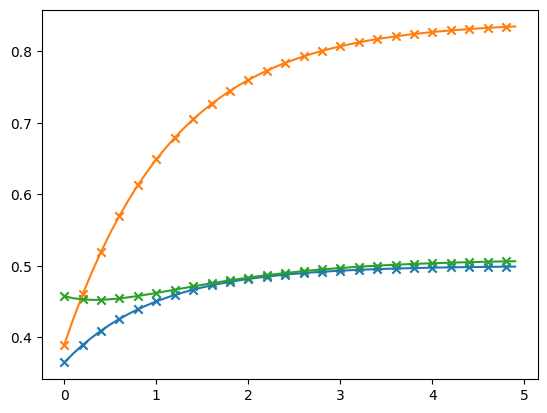

In [316]:

T_MAX = 5
NEURON_NUM = 3

W = np.random.random((NEURON_NUM, NEURON_NUM))*3
mask = np.random.random((NEURON_NUM, NEURON_NUM)) >= 1 - 0.3

W[mask] *= 0

mask = np.random.random((NEURON_NUM, NEURON_NUM)) >= 0.5

W[mask] *= -1

W = np.round(W)

I = np.abs(np.random.random(NEURON_NUM))
mask = np.random.random(NEURON_NUM) >= 1 - 0.3
I[mask] *= 0


initial_state = np.abs(np.random.random(NEURON_NUM) * 1)

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = initial_state, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(W, NP_firing_rate_fun, I),
                atol = 1e-8, rtol=1e-8)
data_train = sol.y[:, ::2]
t_train = sol.t[::2]



for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i])
    plt.scatter(t_train, data_train[i, :], marker="x")

plt.show()

In [317]:
saved_W = W.copy()
saved_I = I.copy()
saved_x0 = initial_state.copy()

np.savetxt("./cool_parameters/W_case2.np", saved_W)
np.savetxt("./cool_parameters/I_case2.np", saved_I)
np.savetxt("./cool_parameters/x0_case2.np", saved_x0)

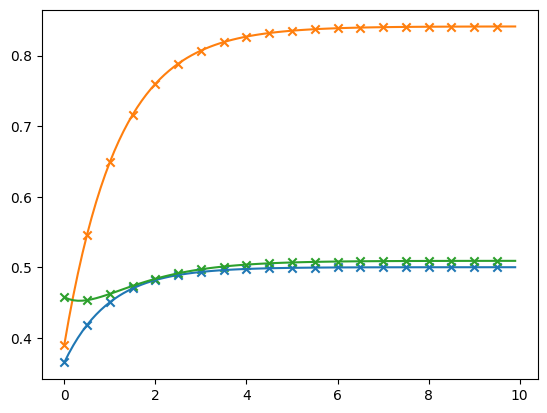

In [321]:
NEURON_NUM = 3
T_MAX = 10

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

                
data_train = sol.y[:, ::5]
t_train = sol.t[::5]



for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i])
    plt.scatter(t_train, data_train[i, :], marker="x")

plt.show()

Text(0.5, 1.0, 'Weights matrix (randomly generated)')

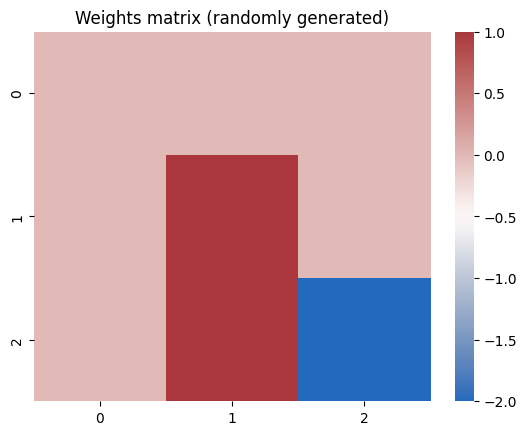

In [323]:
import seaborn as sns

sns.heatmap(W, cmap="vlag")
plt.title("Weights matrix (randomly generated)")

In [324]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class many_monkeys_mixed(nn.Module):
    def __init__(self, I0):
        super().__init__()


        self.register_buffer("I0", torch.tensor(I0, dtype=torch.float32))
        self.register_parameter("W", nn.Parameter(torch.zeros((NEURON_NUM, NEURON_NUM))))

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1),
            nn.Softplus()
        )

        # self.register_parameter("W", nn.Parameter(torch.tensor(saved_W, dtype=torch.float32))) # cheating mode

    def forward(self, t, data):
        x = self.I0 + self.W @ data.squeeze()
        x = x.unsqueeze(-1)
        out = self.net(x).squeeze(-1)
        return - data + out



In [335]:
# Train (fake) UDE network to training data
from tqdm import tqdm 
mixed_monkeys = many_monkeys_mixed(I)

optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.01)

x0_torch = torch.tensor(initial_state, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T
W_tensor = torch.tensor(saved_W, dtype=torch.float32)


print("Epoch\tLoss (L2 norm)\t2-norm difference in weight matrixes")
for EPOCH in (range(1, 10000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]
    # promote matrix sparsity by including a l1 penality term
    matrix_sparsity = torch.sum(torch.abs(mixed_monkeys.W))


    loss_norm = loss_norm
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")


Epoch	Loss (L2 norm)	2-norm difference in weight matrixes
1	8.381899E-02	2.457824
2	5.120561E-02	2.456596
3	3.073240E-02	2.453214
4	1.443481E-02	2.449028
5	4.161333E-03	2.444944
6	4.165410E-03	2.442273
7	9.280887E-03	2.440381
8	7.648950E-03	2.439801
9	3.845951E-03	2.439900
10	1.384858E-03	2.439853
11	1.977045E-03	2.439335
12	3.180672E-03	2.438303
13	3.485032E-03	2.436893
14	2.667380E-03	2.435304
15	1.337089E-03	2.433705
16	5.543554E-04	2.432212
17	6.587348E-04	2.430913
18	1.190125E-03	2.429886
19	1.526353E-03	2.429172
20	1.395322E-03	2.428738
21	9.214549E-04	2.428494
22	4.659813E-04	2.428335
23	2.694507E-04	2.428182
24	3.501860E-04	2.427973
25	5.600107E-04	2.427670
26	7.111371E-04	2.427253
27	6.885484E-04	2.426741
28	5.226676E-04	2.426174
29	3.296733E-04	2.425603
30	2.221871E-04	2.425074
31	2.393622E-04	2.424620
32	3.319290E-04	2.424258
33	4.133479E-04	2.423973
34	4.188754E-04	2.423763
35	3.543717E-04	2.423627
36	2.715182E-04	2.423547
37	2.156723E-04	2.423484
38	2.133390E-04	2.423396
3

In [ ]:
torch.save(optimizer.state_dict(), "./tmp/checkpoint1_optimizer.x")
torch.save(mixed_monkeys.state_dict(), "./tmp/checkpoint1.x")


In [363]:
mixed_monkeys = many_monkeys_mixed(I)
optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.01)

mixed_monkeys.load_state_dict(torch.load("./tmp/checkpoint1.x"))
optimizer.load_state_dict(torch.load("./tmp/checkpoint1_optimizer.x"))

In [364]:
for group in optimizer.param_groups:
    group['lr'] = 0.05

for EPOCH in (range(10000, 11000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]
    # promote matrix sparsity by including a l1 penality term

    loss_norm = loss_norm 
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")


10000	8.858451E-07	1.923703
10001	4.851918E-05	1.922694
10002	6.754699E-03	1.924337
10003	7.862343E-05	1.925815
10004	4.328067E-03	1.925575
10005	1.490340E-03	1.924358
10006	1.400906E-03	1.923035
10007	1.480084E-03	1.922324
10008	7.879495E-04	1.922359
10009	1.028196E-03	1.922754
10010	3.734695E-04	1.922843
10011	6.034713E-04	1.922477
10012	7.921547E-04	1.921836
10013	3.489994E-04	1.921225
10014	1.308864E-04	1.920885
10015	5.101726E-04	1.920887
10016	3.104612E-04	1.921058
10017	5.865031E-05	1.921199
10018	3.098041E-04	1.921164
10019	3.514113E-04	1.920944
10020	1.444080E-04	1.920567
10021	9.645343E-05	1.920179
10022	2.166251E-04	1.920000
10023	1.886630E-04	1.920085
10024	1.021576E-04	1.920303
10025	1.184976E-04	1.920454
10026	1.567799E-04	1.920414
10027	1.358043E-04	1.920182
10028	8.580916E-05	1.919885
10029	9.065156E-05	1.919706
10030	1.143604E-04	1.919736
10031	1.101843E-04	1.919925
10032	5.572321E-05	1.920063
10033	1.029974E-04	1.919979
10034	9.469892E-05	1.919713
10035	4.466385E-05	1

In [365]:
torch.save(optimizer.state_dict(), "./tmp/checkpoint2_optimizer.x")
torch.save(mixed_monkeys.state_dict(), "./tmp/checkpoint2.x")


In [366]:
mixed_monkeys = many_monkeys_mixed(I)
optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.01)

mixed_monkeys.load_state_dict(torch.load("./tmp/checkpoint2.x"))
optimizer.load_state_dict(torch.load("./tmp/checkpoint2_optimizer.x"))

In [367]:
for EPOCH in (range(11000, 20000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]
    # promote matrix sparsity by including a l1 penality term

    loss_norm = loss_norm 
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")


11000	2.806283E-07	1.907356
11001	4.969347E-07	1.907363
11002	3.658435E-07	1.907361
11003	1.624404E-07	1.907359
11004	2.588736E-07	1.907363
11005	3.896893E-07	1.907352
11006	2.812320E-07	1.907356
11007	1.573578E-07	1.907356
11008	2.291738E-07	1.907346
11009	3.103084E-07	1.907352
11010	2.352114E-07	1.907349
11011	1.554523E-07	1.907346
11012	2.019427E-07	1.907350
11013	2.575745E-07	1.907346
11014	2.091992E-07	1.907350
11015	1.535249E-07	1.907351
11016	1.803694E-07	1.907347
11017	2.190127E-07	1.907353
11018	1.929480E-07	1.907349
11019	1.526436E-07	1.907347
11020	1.654551E-07	1.907349
11021	1.934794E-07	1.907344
11022	1.811371E-07	1.907343
11023	1.522662E-07	1.907341
11024	1.550933E-07	1.907338
11025	1.749743E-07	1.907339
11026	1.721286E-07	1.907334
11027	1.525367E-07	1.907333
11028	1.490689E-07	1.907335
11029	1.620539E-07	1.907331
11030	1.644057E-07	1.907332
11031	1.524076E-07	1.907332
11032	1.461318E-07	1.907330
11033	1.530019E-07	1.907331
11034	1.578892E-07	1.907329
11035	1.518661E-07	1

In [372]:
torch.save(optimizer.state_dict(), "./tmp/checkpoint3_optimizer.x")
torch.save(mixed_monkeys.state_dict(), "./tmp/checkpoint3.x")


In [382]:
mixed_monkeys = many_monkeys_mixed(I)
optimizer = optim.Adamax(mixed_monkeys.parameters(), lr=0.01)

mixed_monkeys.load_state_dict(torch.load("./tmp/checkpoint3.x"))
optimizer.load_state_dict(torch.load("./tmp/checkpoint3_optimizer.x"))

In [383]:
for EPOCH in (range(20000, 21000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(mixed_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='rk4')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]
    # promote matrix sparsity by including a l1 penality term
    matrix_sparsity = torch.sum(torch.abs(mixed_monkeys.W))

    loss_norm = loss_norm + 1e-7 * matrix_sparsity
    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{torch.norm(mixed_monkeys.W-W_tensor, 2):4f}")


20000	2.038529E-06	1.550199
20001	1.362249E-06	1.549903
20002	8.071394E-07	1.549943
20003	5.470179E-07	1.549959
20004	6.602953E-07	1.549753
20005	9.488862E-07	1.549886
20006	1.257507E-06	1.549738
20007	1.497571E-06	1.549840
20008	1.603197E-06	1.549680
20009	1.603127E-06	1.549889
20010	1.597940E-06	1.549690
20011	1.541897E-06	1.549834
20012	1.571357E-06	1.549722
20013	1.631223E-06	1.549802
20014	1.832047E-06	1.549621
20015	2.040335E-06	1.549823
20016	2.347048E-06	1.549529
20017	2.609400E-06	1.549768
20018	2.858909E-06	1.549491
20019	3.007342E-06	1.549718
20020	3.092930E-06	1.549421
20021	3.067875E-06	1.549715
20022	2.997892E-06	1.549402
20023	2.830610E-06	1.549676
20024	2.665991E-06	1.549426
20025	2.470550E-06	1.549643
20026	2.335355E-06	1.549410
20027	2.242580E-06	1.549634
20028	2.292938E-06	1.549390
20029	2.436009E-06	1.549597
20030	2.853016E-06	1.549338
20031	3.458386E-06	1.549562
20032	4.588649E-06	1.549174
20033	6.025361E-06	1.549571
20034	8.258841E-06	1.548968
20035	1.083677E-05	1

In [ ]:
torch.save(optimizer.state_dict(), "./models_weights/mixed_monkeys.dinomeng")

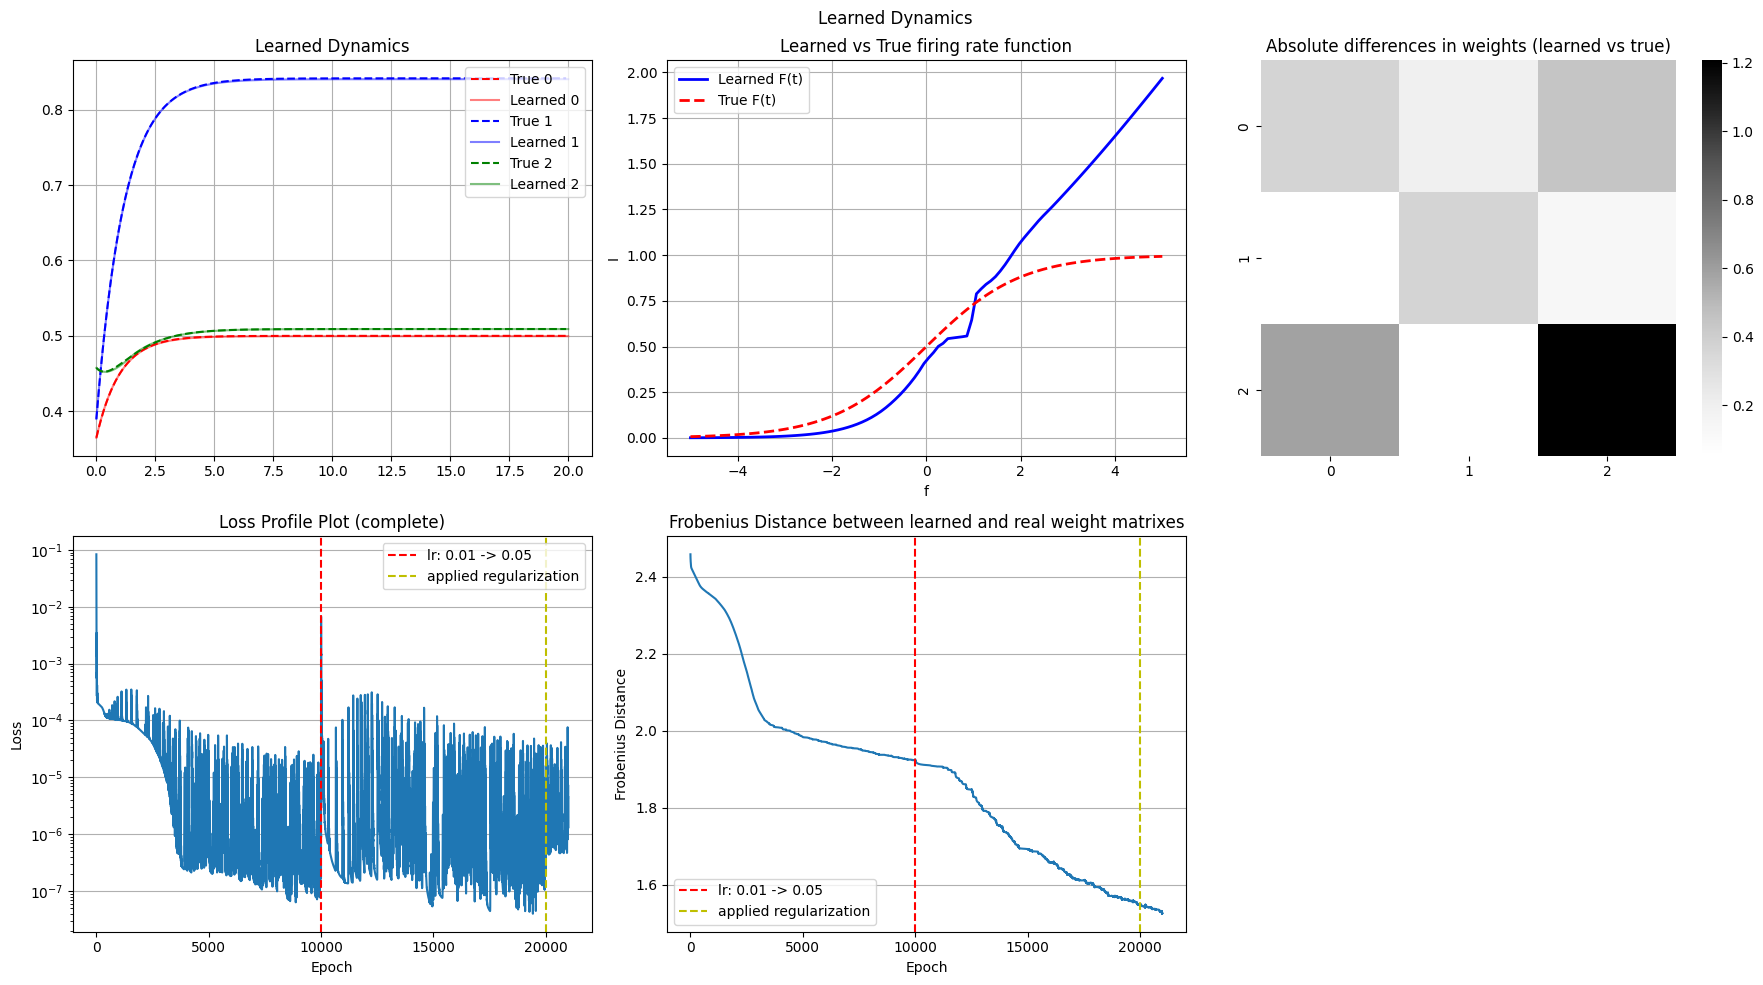

In [ ]:
plt.figure(figsize=(18, 10))
plt.suptitle("Case 2: Learning weights and f-i function simultaneously")

# Plot 1: dynamics

t_plot = torch.linspace(-5, 5, 100)
with torch.no_grad():
    I_learned = torch.stack([mixed_monkeys.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()

T_MAX = 20

plt.subplot(2, 3, 1)
sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

plt.suptitle("Learned Dynamics")

pred = odeint(mixed_monkeys, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

colors = ['r', 'b', 'g', 'y', 'k']

for i in range(3):
    plt.plot(sol.t, sol.y[i, :], f"{colors[i]}--", label=f"True {i}")
    plt.plot(np.arange(0, T_MAX, 0.01), pred[:, i].cpu().detach().numpy(), f"{colors[i]}",label=f"Learned {i}", alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend(loc="upper right")

# --- plot 2: firing rate


plt.subplot(2, 3, 2)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')
t_true = np.linspace(-5, 5, 100)
I_true = NP_firing_rate_fun(t_true)
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('f')
plt.ylabel('I')
plt.legend()
plt.title('Learned vs True firing rate function')
plt.grid()


# Plot 3: Plot difference between weight matrixes

plt.subplot(2,3, 3)

with torch.no_grad():
    sns.heatmap((np.abs(mixed_monkeys.W.detach().numpy()- W)), cmap="Greys")
plt.title("Absolute differences in weights (learned vs true)")


# Plot 4: losses with semilogy
losses_data = np.loadtxt(r"./losses/mixed_monkeys_losses.txt", delimiter="\t")

plt.subplot(2, 3, 4)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.axvline(10000, color='r', linestyle='--',label="lr: 0.01 -> 0.05")
plt.axvline(20000, color='y', linestyle='--',label="applied regularization")
plt.legend()
plt.title("Loss Profile Plot (complete)")

# plot 5: 2-norm between matrixes

plt.subplot(2,3, 5)
plt.plot(losses_data[:, 0], losses_data[:, 2])
plt.xlabel("Epoch")
plt.ylabel("Frobenius Distance")
plt.title("Frobenius Distance between learned and real weight matrixes")
plt.axvline(10000, color='r', linestyle='--',label="lr: 0.01 -> 0.05")
plt.axvline(20000, color='y', linestyle='--',label="applied regularization")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()


todo: try with dropout or similar regularization techniques

vedere libro murphy (prob. ml)

### Case 3: Learning Transfer function and impulses

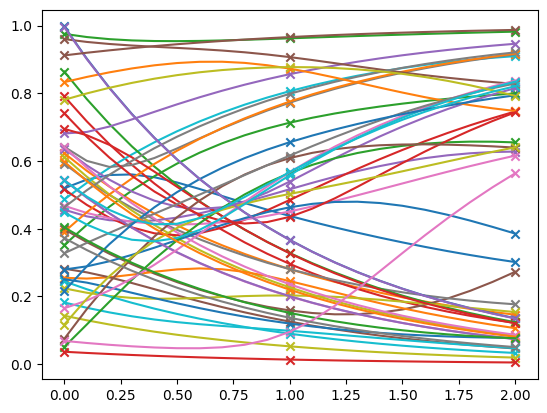

In [509]:

T_MAX = 2.1
NEURON_NUM = 50

W = np.random.random((NEURON_NUM, NEURON_NUM))*3
mask = np.random.random((NEURON_NUM, NEURON_NUM)) >= 1 - 0.3

W[mask] *= 0

mask = np.random.random((NEURON_NUM, NEURON_NUM)) >= 0.5

W[mask] *= -1

W = np.round(W)

I = np.abs(np.random.random(NEURON_NUM))
mask = np.random.random(NEURON_NUM) >= 1 - 0.3
I[mask] *= 0


initial_state = np.abs(np.random.random(NEURON_NUM) * 1)

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = initial_state, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(W, NP_firing_rate_fun, I),
                atol = 1e-8, rtol=1e-8)

                
data_train = sol.y[:, ::10]
t_train = sol.t[::10]



for i in range(NEURON_NUM):
    plt.plot(sol.t, sol.y[i])
    plt.scatter(t_train, data_train[i, :], marker="x")

plt.show()

In [510]:
saved_W = W.copy()
saved_I = I.copy()
saved_x0 = initial_state.copy()

np.savetxt("./cool_parameters/W_case3.np", saved_W)
np.savetxt("./cool_parameters/I_case3.np", saved_I)
np.savetxt("./cool_parameters/x0_case3.np", saved_x0)

In [ ]:
def TORCH_firing_rate_fun(x):
    return 1 / (1 + torch.exp(-x))

class many_monkeys_impulses(nn.Module):
    def __init__(self, W):
        super().__init__()

        self.register_parameter("I0", nn.Parameter(torch.zeros(NEURON_NUM, dtype=torch.float32)))
        self.register_buffer("W", torch.tensor(W, dtype=torch.float32))

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1),
            nn.Softplus()
        )

        # self.register_parameter("W", nn.Parameter(torch.tensor(saved_W, dtype=torch.float32))) # cheating mode

    def forward(self, t, data):
        x = nn.functional.softplus(self.I0) + self.W @ data.squeeze() # softplus for a soft-constraint on non negativity
        x = x.unsqueeze(-1)
        out = self.net(x).squeeze(-1)
        return - data + out



In [557]:
# Train (fake) UDE network to training data
from tqdm import tqdm 
transfer_monkeys = many_monkeys_impulses(saved_W)

optimizer = optim.Adam(transfer_monkeys.parameters(), lr=0.003)

x0_torch = torch.tensor(initial_state, dtype=torch.float32)
T_train_torch = torch.tensor(t_train, dtype=torch.float32)
data_train_torch = torch.tensor(data_train, dtype=torch.float32).T
W_tensor = torch.tensor(saved_W, dtype=torch.float32)

print("Epoch\tLoss (L2 norm)\tL2-norm inducted distance between learnt and real external impulse constant")
for EPOCH in (range(1, 2000)):
    optimizer.zero_grad()

    # get forward solution
    info = odeint(transfer_monkeys, x0_torch, T_train_torch,
                  rtol=1e-5, atol=1e-6, method='dopri5')

    # calculate loss
    loss_norm = torch.norm((info - data_train_torch), 2)**2 
    loss_norm = loss_norm / T_train_torch.shape[0]

    loss_norm.backward()

    optimizer.step()

    with torch.no_grad():
        print(f"{EPOCH}\t{loss_norm:.6E}\t{np.linalg.norm(nn.functional.softplus(transfer_monkeys.I0).detach().numpy() - saved_I, 2):.7f}")


Epoch	Loss (L2 norm)	L2-norm inducted distance between learnt and real external impulse constant
1	7.435877E+00	3.7134886
2	3.084650E+00	3.7170258
3	1.796257E+00	3.7171175
4	1.120139E+00	3.7164325
5	7.280459E-01	3.7155189
6	4.757277E-01	3.7144307
7	3.288741E-01	3.7130730
8	2.148064E-01	3.7117455
9	1.513864E-01	3.7106062
10	1.080413E-01	3.7096469
11	8.137754E-02	3.7087465
12	7.518822E-02	3.7077990
13	6.504288E-02	3.7069867
14	6.579476E-02	3.7063789
15	6.312100E-02	3.7059270
16	6.062284E-02	3.7054729
17	6.174065E-02	3.7049251
18	5.843071E-02	3.7043748
19	6.167891E-02	3.7037806
20	5.917777E-02	3.7029997
21	6.374937E-02	3.7019570
22	6.160412E-02	3.7007496
23	6.480824E-02	3.6994286
24	6.150459E-02	3.6979804
25	6.187548E-02	3.6963931
26	5.696527E-02	3.6947361
27	5.498688E-02	3.6930734
28	5.003377E-02	3.6914082
29	4.678211E-02	3.6897240
30	4.290644E-02	3.6880505
31	3.904173E-02	3.6864342
32	3.647684E-02	3.6848927
33	3.254956E-02	3.6834046
34	3.040796E-02	3.6819458
35	2.731533E-02	3.6805335
36

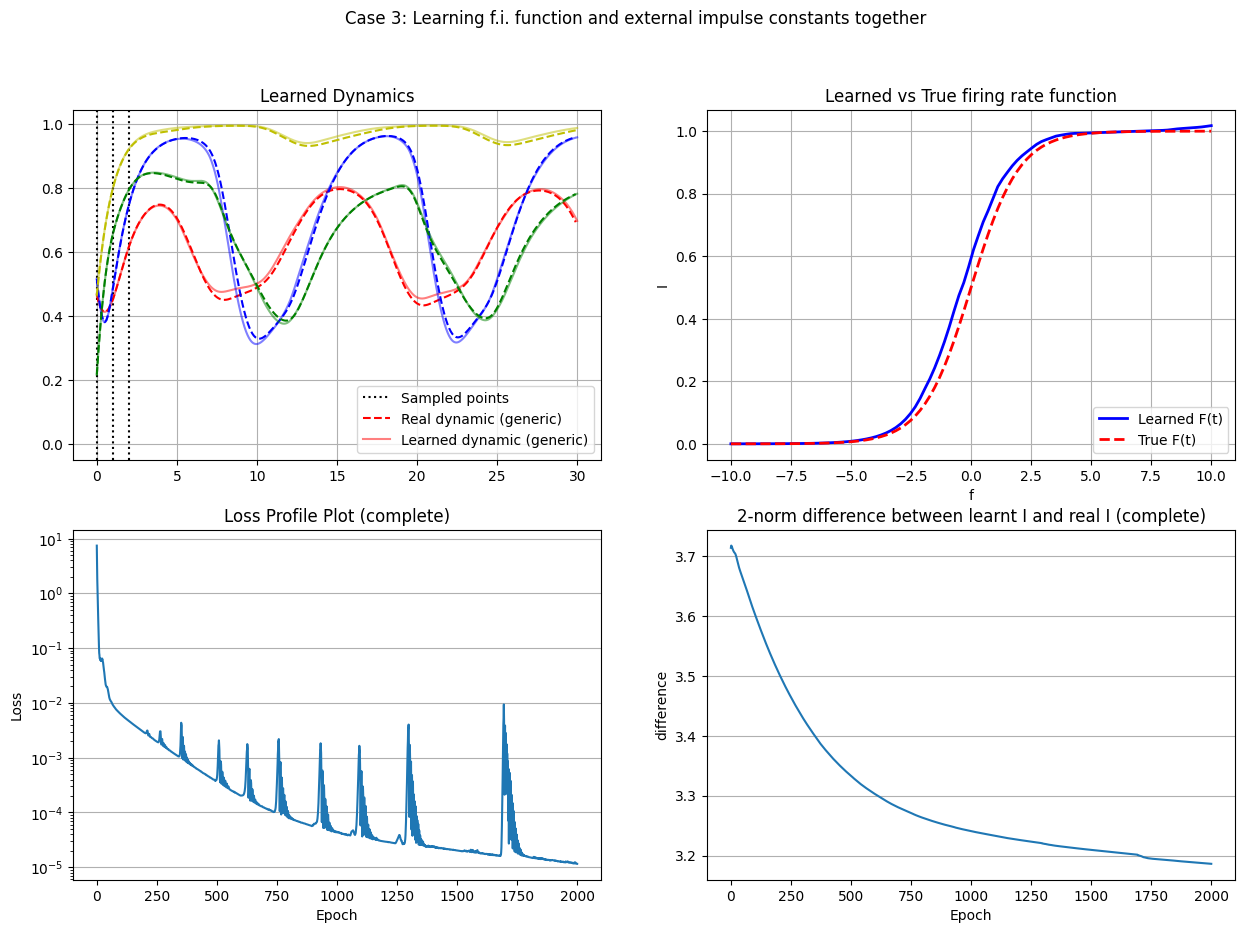

In [577]:
plt.figure(figsize=(15, 10))
plt.suptitle("Case 3: Learning f.i. function and external impulse constants together")

# Plot 1: dynamics

T_MAX = 30

plt.subplot(2, 2, 1)

sol = solve_ivp(many_monkeys, [0,T_MAX],
                y0 = saved_x0, 
                t_eval = np.arange(0, T_MAX, 0.1), 
                args=(saved_W, NP_firing_rate_fun, saved_I),
                atol = 1e-8, rtol=1e-8)

plt.axvline(0, label="Sampled points", color='k', linestyle=':')
plt.axvline(1,  color='k', linestyle=':')
plt.axvline(2,color='k', linestyle=':')

plt.plot([0], [0],color='r', linestyle='--', label="Real dynamic (generic)")
plt.plot([0], [0],color='r', label="Learned dynamic (generic)", alpha=0.5)


pred = odeint(transfer_monkeys, x0_torch, torch.arange(0, T_MAX, 0.01), method='dopri5', atol=1e-5, rtol=1e-5)

colors = ['r', 'b', 'g', 'y', 'k']

rand_indexes = np.random.randint(low=0, high=NEURON_NUM, size=(4))

for j, i in enumerate(rand_indexes):
    plt.plot(sol.t, sol.y[i, :], f"{colors[j]}--")
    plt.plot(np.arange(0, T_MAX, 0.01), pred[:, i].cpu().detach().numpy() ,f'{colors[j]}' , alpha=0.5)

plt.grid()

plt.title("Learned Dynamics")
plt.legend(loc="lower right")

# --- plot 2: firing rate
t_plot = torch.linspace(-10, 10, 100)
with torch.no_grad():
    I_learned = torch.stack([transfer_monkeys.net(torch.tensor([[t]], dtype=torch.float32)) 
                             for t in t_plot]).squeeze()


plt.subplot(2, 2, 2)
plt.plot(t_plot.numpy(), I_learned.numpy(), 'b-', linewidth=2, label='Learned F(t)')
t_true = np.linspace(-10, 10, 100)
I_true = NP_firing_rate_fun(t_true)
plt.plot(t_true, I_true, 'r--', linewidth=2, label='True F(t)')
plt.xlabel('f')
plt.ylabel('I')
plt.legend(loc="lower right")
plt.title('Learned vs True firing rate function')
plt.grid()

# Plot 4: losses with semilogy
losses_data = np.loadtxt(r"./losses/transfer_monkeys_losses.txt", delimiter="\t")

plt.subplot(2, 2, 3)
plt.semilogy(losses_data[:, 0], losses_data[:, 1])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(axis="y")
plt.title("Loss Profile Plot (complete)")

# Plot 4: losses with semilogy
plt.subplot(2, 2, 4)
plt.plot(losses_data[:, 0], losses_data[:, 2])
plt.xlabel("Epoch")
plt.ylabel("difference")
plt.grid(axis="y")
plt.title("2-norm difference between learnt I and real I (complete)")

plt.show()